# watanabe2021 — Watanabe & Yamana (2020) — Topological Measurement of DNNs Using PH

Builds the FCN's **directed clique complex** with path-product relevance and integer-index filtration (GUDHI), then runs H1 PH.  Signature result: a wide 'belt' of H1 generators above the diagonal.


## What the paper does

Reads the trained **fully-connected head** as a weighted directed graph and studies its loops with persistent homology.  Each weight is turned into a *relevance* `R_ij = w_ij / Σ_k w_kj` (column-normalised per target neuron), and the network is turned into a **directed clique complex**:

* a **direct edge** (consecutive layers) is born at its relevance,
* an **induced edge** between layers two apart is born at the strongest two-hop **path product** `maxⱼ R[i,j]·R[j,k]`,
* a **triangle** `{i,j,k}` is born at the path product `R[i,j]·R[j,k]`,

and every simplex's filtration *value* is the **integer threshold index** (1–64) of the paper's descending relevance schedule.

**Methodology:** FCN weights → relevance → directed clique complex (path-product, integer filtration) → `H1` PH.

**Expected result:** because a path product of two relevances (each ≤ 1) is far smaller than either edge, triangles enter the filtration much later than the loops they fill — so `H1` generators form a wide **belt above the diagonal** (paper Fig. 2), *not* points hugging it.

> This is a genuine **fix**: the old preset ran a *flag*-complex PH on a similarity matrix (triangle = max of its edges), which squashed the diagram onto the diagonal.  The toolkit now builds the directed clique complex (`run_ph(..., input_complex='directed_clique')`), matching the reference implementation bit-for-bit.


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/2106.03016](https://arxiv.org/abs/2106.03016)
- **Venue:** ISAIM 2020 / AIKE 2020 (Pruning)
- **Datasets used:** CIFAR-10.
- **Models used:** CNN feature extractor + a fully-connected head (the paper uses FCN 300→100→10).  Here: a small CNN_FCN whose linear head is the FCN the complex is built on.
- **Headline result to aim for:** The H1 persistence diagram of the FCN's directed clique complex shows a characteristic belt of loop generators well above the diagonal (paper Fig. 2); the same complex's representative cycles drive PHPM pruning.
- **Reference code:** [https://github.com/satoru-watanabe-aw/DNNtopology](https://github.com/satoru-watanabe-aw/DNNtopology)

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook now runs on real data.**  A tiny model is trained briefly on the local dataset cache under `data/`.  Headline numbers won't match the paper (that needs full training on GPU); the *qualitative* behaviour the paper reports should still appear.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN2, train_briefly, extract_snapshot, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'

## 1. Load dataset + train a small model briefly


In [2]:
# CNN with a 2-layer FCN head on CIFAR-10.  The clique complex needs
# >=2 consecutive Dense layers, so we use CNN_FCN2 (not SmallCNN).
X_tr, y_tr = load_cifar10('train', n_samples=10000)
X_te, y_te = load_cifar10('test',  n_samples=1000)

model = CNN_FCN2(in_channels=3, num_classes=10, conv_channels=(32,64,128), hidden=64)
# aspects=['weights'] -> the extractor captures the linear (FCN) weights.
view  = train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=12,
                      aspects=['weights'], device=DEVICE, verbose=False)
print('final test acc:', view.final_snapshot.accuracy)
print('FCN head weight matrices:',
      [W.shape for W in view.final_snapshot.weight_matrices()])


paper_reproduce/_torch_setup.py:525: UserWarning: Model 'Sequential' has both fully-connected (linear / SoRO) and conv layers. Defaulting to the fully-connected layers. Pass layer_selection='all_linear', 'all_conv', 'soro', 'linear_and_conv', 'all', or a list of names/indices to suppress this warning.
  extractor = TrainingExtractor(


final test acc: 0.548
FCN head weight matrices: [(128, 64), (64, 10)]


## 2. Reproduce via `TDAPipeline.from_paper` — model-first

We hand the trained model object straight to the pipeline: `from_paper` already knows what this paper needs, and the pipeline's model-adapter extracts it for us — no manual feature pulling required.


In [3]:
pipe = TDAPipeline.from_paper("watanabe2021")
pipe.explain()


TDAPipeline — Watanabe & Yamana (2020)
  Stage 1: builder = weight_graph
             edge_weight = 'relevance'
             graph_scope = 'full'
             induced_paths = False
             node_feature_fn = None
  Stage 2: tool    = ph
             max_dim = 1
             input_complex = 'directed_clique'
             relevance_mode = 'positive'
  Default plot   : .plot('diagram')


"TDAPipeline — Watanabe & Yamana (2020)\n  Stage 1: builder = weight_graph\n             edge_weight = 'relevance'\n             graph_scope = 'full'\n             induced_paths = False\n             node_feature_fn = None\n  Stage 2: tool    = ph\n             max_dim = 1\n             input_complex = 'directed_clique'\n             relevance_mode = 'positive'\n  Default plot   : .plot('diagram')"

TopoResult(tool='ph')
  paper       : Watanabe & Yamana (2020)
  data        : ph_result (H0: 201 bars, H1: 4356 bars)
  statistics  : H0_total_persistence, H0_persistence_norm, H0_betti_curve, H0_persistence_entropy, H1_total_persistence, H1_persistence_norm (+2 more)
  plots       :
    .plot('diagram') — Birth-vs-death scatter of persistence pairs.
    .plot('barcode') — Horizontal bars from birth to death, sorted by birth.
    .plot('betti_curve') — Step function of Betti_d across the filtration range.
  config keys : complex, mode, max_dim, schedule_steps


"TopoResult(tool='ph')\n  paper       : Watanabe & Yamana (2020)\n  data        : ph_result (H0: 201 bars, H1: 4356 bars)\n  statistics  : H0_total_persistence, H0_persistence_norm, H0_betti_curve, H0_persistence_entropy, H1_total_persistence, H1_persistence_norm (+2 more)\n  plots       :\n    .plot('diagram') — Birth-vs-death scatter of persistence pairs.\n    .plot('barcode') — Horizontal bars from birth to death, sorted by birth.\n    .plot('betti_curve') — Step function of Betti_d across the filtration range.\n  config keys : complex, mode, max_dim, schedule_steps"

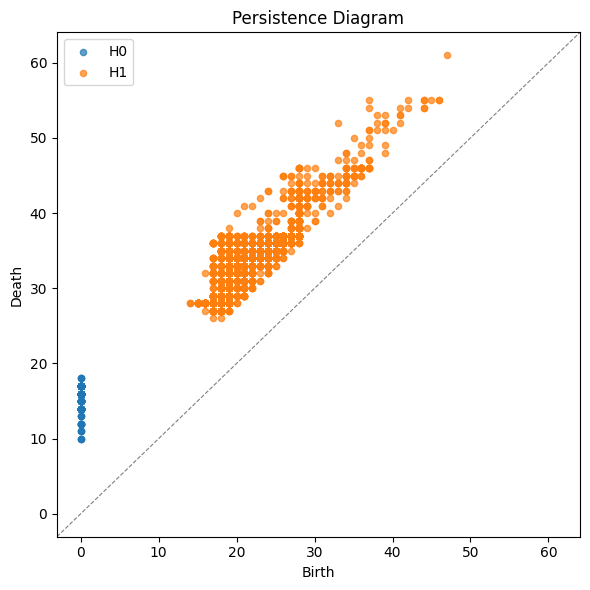

In [4]:
result, fig = pipe.reproduce(view)
result.describe()


## 3. Paper-specific follow-up plot


H1 generators: 4356  |  mean lifetime (belt width): 11.3


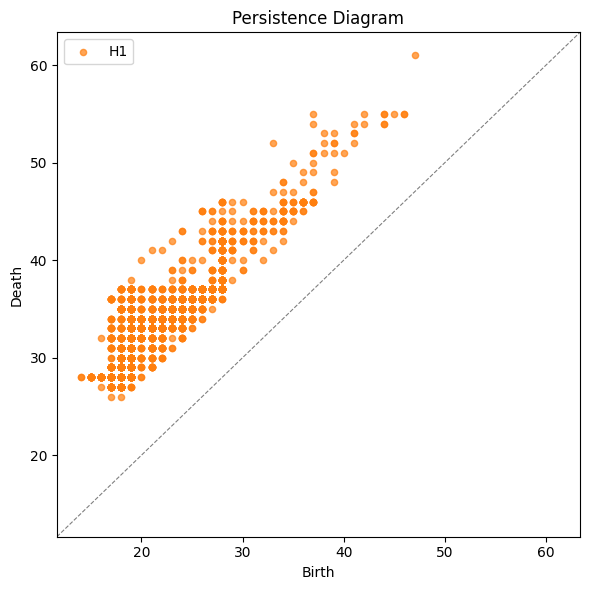

In [5]:
# H1 diagram: the belt of loop generators above the diagonal.
fig = result.plot("diagram", dims=[1])
d1 = result.diagram(1)
print(f'H1 generators: {len(d1)}  |  mean lifetime (belt width): '
      f'{(d1[:,1]-d1[:,0]).mean():.1f}')


## 5. PHPM pruning — prune the FCN by its strongest H1 loops

Watanabe & Yamana's **PHPM** pruning keeps the weight-edges carrying the strongest H1 loops (smallest `birth + death`) and zeroes the rest, comparing against the **global magnitude pruning (GMP)** baseline.  PHPM uses the *absolute*-relevance complex, so we rebuild the PH with `relevance_mode='absolute'` and read its representative cycles from `tanc.applications.pruning`.


In [6]:
import copy, torch
from tanc.applications import (
    phpm_pruning_mask, gmp_pruning_mask, prune_diagnostics)

# PHPM uses |w| relevance; rebuild the directed-clique PH in that mode.
ph = TDAPipeline.from_paper('watanabe2021',
                            tool_kwargs__relevance_mode='absolute').fit(view)
W = view.final_snapshot.weight_matrices()      # [(feat,hidden),(hidden,10)]

def eval_with_masks(masks):
    '''Zero the FCN Dense weights per mask (N_in,N_out -> torch (out,in)) and score.'''
    m = copy.deepcopy(model).to('cpu').eval()
    lins = [l for l in m.modules() if isinstance(l, torch.nn.Linear)]
    with torch.no_grad():
        for layer, mask in zip(lins, masks):
            layer.weight.mul_(torch.as_tensor(mask.T, dtype=layer.weight.dtype))
        pred = m(torch.as_tensor(X_te, dtype=torch.float32)).argmax(1).numpy()
    return float((pred == y_te).mean())

ratios = [0.0, 0.6, 0.7, 0.8, 0.9]
phpm_acc, gmp_acc = [], []
for r in ratios:
    if r == 0.0:
        a = eval_with_masks([np.ones_like(w, bool) for w in W])
        phpm_acc.append(a); gmp_acc.append(a); continue
    phpm_acc.append(eval_with_masks(phpm_pruning_mask(W, ph, r)))
    gmp_acc.append(eval_with_masks(gmp_pruning_mask(W, r, per_layer=True)))
    print(f'ratio {r}:  PHPM={phpm_acc[-1]:.3f}  GMP={gmp_acc[-1]:.3f}')


ratio 0.6:  PHPM=0.562  GMP=0.538


ratio 0.7:  PHPM=0.554  GMP=0.525


ratio 0.8:  PHPM=0.431  GMP=0.455


ratio 0.9:  PHPM=0.364  GMP=0.188


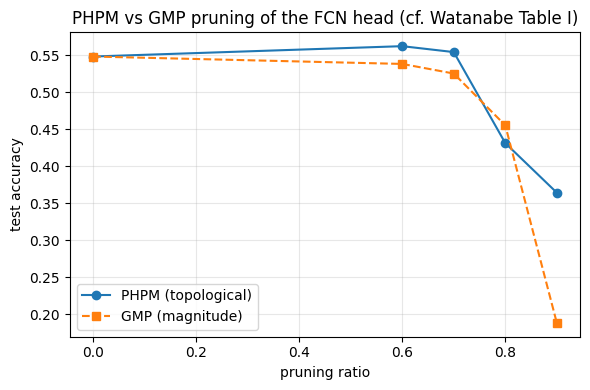

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(ratios, phpm_acc, 'o-', label='PHPM (topological)')
plt.plot(ratios, gmp_acc, 's--', label='GMP (magnitude)')
plt.xlabel('pruning ratio'); plt.ylabel('test accuracy')
plt.title('PHPM vs GMP pruning of the FCN head (cf. Watanabe Table I)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Notes & gaps

* **Reproduced faithfully:** the directed clique complex with path-product integer filtration — identical H1 to the reference `DNNtopology` / `phpm.py` implementation.
* `result.ph_result.metadata['watanabe']` carries the H1 representative simplices; the companion **PHPM pruning** notebook uses them to prune the FCN by its strongest loops.
* The paper's FCN is 300→100→10; scale `feat`/`hidden` up for a denser belt closer to their Fig. 2.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| architecture | FCN 300→100→10 | a smaller CNN + FC head | runtime; scale `feat`/`hidden` up to approach the paper's figure |
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
